## 1. Importação das Bibliotecas necessárias

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


---
## 2. Carregamento de Informações Gerais do Dataset


In [107]:
data = load_breast_cancer()
X_train = pd.DataFrame(data.data, columns=data.feature_names)
Y_train = pd.Series(data.target, name='target')
X_train['diagnosis'] = Y_train.map({1: 'Benigno', 0: 'Maligno'})

print("INFORMAÇÕES GERAIS DO DATASET\n")
print(f"Shape (linhas × colunas): {data.data.shape}")
print(f"Total de amostras: {data.data.shape[0]}")
print(f"Total de features: {data.data.shape[1]}")
print(f"Valores alvo: 0 = Maligno | 1 = Benigno")

counts = X_train['diagnosis'].value_counts()
print(f"\n Distribuição das Classes:")
for cls, cnt in counts.items():
    pct = cnt / len(X_train) * 100
    print(f"{cls:>8}: {cnt} amostras ({pct:.1f}%)")


INFORMAÇÕES GERAIS DO DATASET

Shape (linhas × colunas): (569, 30)
Total de amostras: 569
Total de features: 30
Valores alvo: 0 = Maligno | 1 = Benigno

 Distribuição das Classes:
 Benigno: 357 amostras (62.7%)
 Maligno: 212 amostras (37.3%)


---
## 3. Análise Exploratória dos Dados


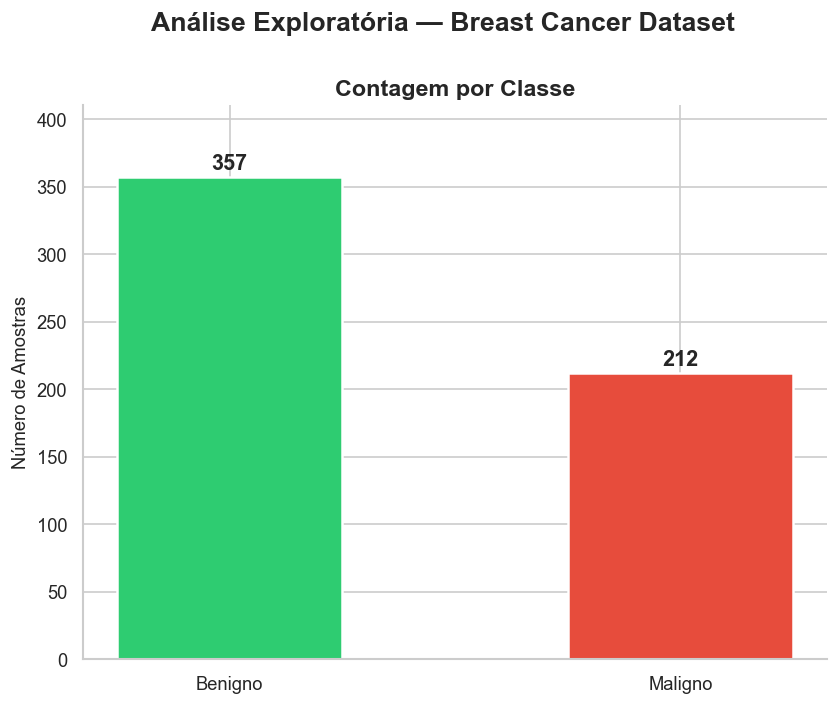

In [78]:
fig, ax1 = plt.subplots(figsize=(8, 6))

COLORS = {'Benigno': '#2ecc71', 'Maligno': '#e74c3c'}
palette = list(COLORS.values())

bars = ax1.bar(counts.index, counts.values, color=palette,
               edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3, 
    str(val), ha='center', va='bottom', fontsize=13, fontweight='bold')
ax1.set_title('Contagem por Classe', fontsize=14, fontweight='bold')
ax1.set_ylabel('Número de Amostras', fontsize=11)
ax1.set_ylim(0, counts.max() * 1.15)
ax1.spines[['top', 'right']].set_visible(False)


fig.suptitle('Análise Exploratória — Breast Cancer Dataset', fontsize=16, fontweight='bold', y=1.01)
plt.savefig('analise_exploratoria.png', bbox_inches='tight', dpi=150)
plt.show()


---
## 4. Pré-processamento com StandardScaler


In [111]:
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Tamanho do conjunto de treino : {X_train.shape}")
print(f"Tamanho do conjunto de teste  : {X_test.shape}")
print(f"\nProporção de classes no treino:")
vals, cnts = np.unique(y_train, return_counts=True)
for v, c in zip(vals, cnts):
    print(f"  Classe {v} ({data.target_names[v]:}): {c} ({c/len(y_train)*100:.1f}%)")


Tamanho do conjunto de treino : (455, 30)
Tamanho do conjunto de teste  : (114, 30)

Proporção de classes no treino:
  Classe 0 (malignant): 170 (37.4%)
  Classe 1 (benign): 285 (62.6%)


In [123]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Comparativo: ANTES × DEPOIS do StandardScaler\n")
print(f"{'Feature':>22}   {'Média Antes':>11}       {'Média Depois':>12}")
for i, feat in enumerate(data.feature_names[:6]):
    print(f"{feat:>22}  {X_train[:, i].mean():>11.3f}    {X_train_scaled[:, i].mean():>12.20f}")


Comparativo: ANTES × DEPOIS do StandardScaler

               Feature   Média Antes       Média Depois
           mean radius       14.067    -0.00000000000000433743
          mean texture       19.247    0.00000000000000224094
        mean perimeter       91.557    -0.00000000000000074373
             mean area      648.541    0.00000000000000015031
       mean smoothness        0.096    0.00000000000000522366
      mean compactness        0.104    -0.00000000000000277580


---
## 5. Treinamento do KNN 
### Testando K de 1 a 20


In [ ]:
from sklearn.model_selection import cross_val_score

k_values = range(1, 21)
train_accuracies = []
test_accuracies  = []
cv_accuracies    = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    
    knn.fit(X_train_scaled, y_train)
    train_accuracies.append(knn.score(X_train_scaled, y_train))
    test_accuracies.append(knn.score(X_test_scaled, y_test))
    
    cv_score = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')

print(" K  Treino   Teste ")
for k, tr, te in zip(k_values, train_accuracies, test_accuracies):
    print(f"{k:2d}  {tr:.4f}  {te:.4f} ")


 K  Treino   Teste 
 1  1.0000  0.9386 
 2  0.9802  0.9298 
 3  0.9780  0.9825 
 4  0.9824  0.9474 
 5  0.9736  0.9561 
 6  0.9780  0.9561 
 7  0.9758  0.9737 
 8  0.9758  0.9737 
 9  0.9736  0.9737 
10  0.9758  0.9649 
11  0.9714  0.9737 
12  0.9692  0.9737 
13  0.9714  0.9737 
14  0.9714  0.9649 
15  0.9692  0.9737 
16  0.9692  0.9737 
17  0.9626  0.9825 
18  0.9670  0.9825 
19  0.9670  0.9737 
20  0.9692  0.9737 


---
## 6. Gráfico Acurácia × K e Escolha do Melhor K


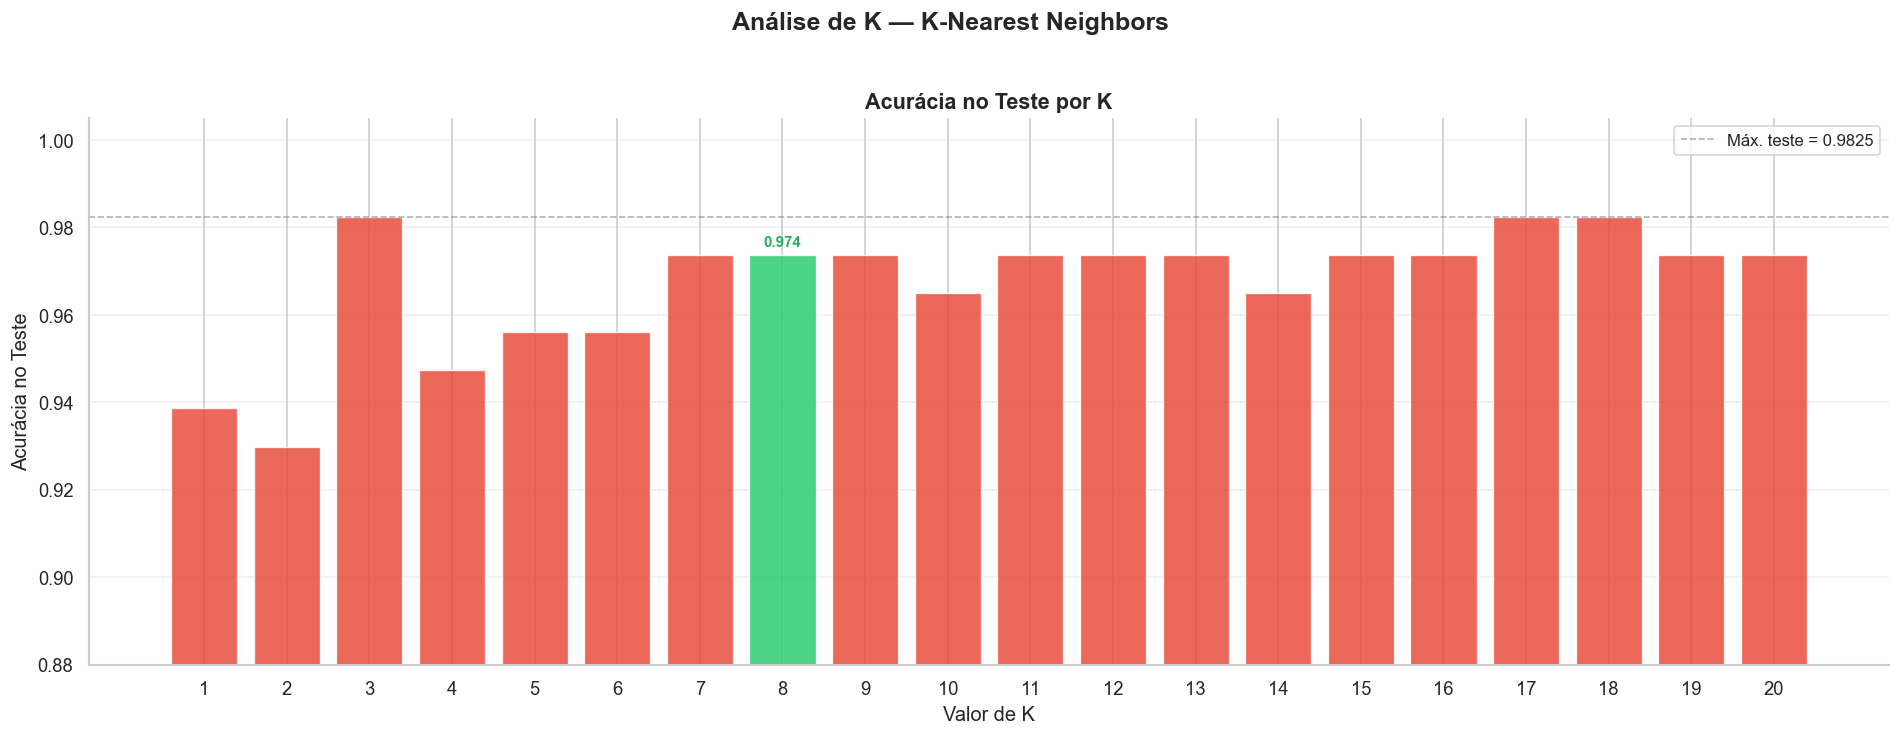


 Melhor K pela Cross-Validation : K = 8  (CV = 0.9714)
 Melhor K pela acurácia no teste : K = 3  (Teste = 0.9825)


In [143]:
best_k_cv   = k_values[np.argmax(cv_accuracies)]
best_k_test = k_values[np.argmax(test_accuracies)]

fig, axes = plt.subplots(figsize=(16, 6))

bar_colors = ['#e74c3c' if k != best_k_cv else '#2ecc71' for k in k_values]
bars = axes.bar(list(k_values), test_accuracies, color=bar_colors,
               edgecolor='white', linewidth=0.8, alpha=0.85)
axes.axhline(y=max(test_accuracies), color='gray', linestyle='--',
            linewidth=1, alpha=0.6, label=f'Máx. teste = {max(test_accuracies):.4f}')
axes.set_xlabel('Valor de K', fontsize=12)
axes.set_ylabel('Acurácia no Teste', fontsize=12)
axes.set_title('Acurácia no Teste por K', fontsize=13, fontweight='bold')
axes.set_xticks(list(k_values))
axes.set_ylim(0.88, 1.005)
axes.legend(fontsize=10)
axes.spines[['top', 'right']].set_visible(False)
axes.grid(True, alpha=0.3, axis='y')

axes.text(best_k_cv, test_accuracies[best_k_cv-1] + 0.002,
         f'{test_accuracies[best_k_cv-1]:.3f}', ha='center', fontsize=9,
         fontweight='bold', color='#27ae60')

plt.suptitle('Análise de K — K-Nearest Neighbors', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('acuracia-vs-k.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"\n Melhor K pela Cross-Validation : K = {best_k_cv}  (CV = {cv_accuracies[best_k_cv-1]:.4f})")
print(f" Melhor K pela acurácia no teste : K = {best_k_test}  (Teste = {test_accuracies[best_k_test-1]:.4f})")


### Justificativa da Escolha do Melhor K

A escolha do **K** é baseada na **Cross-Validation de 5-fold** no conjunto de treino, e *não* na acurácia direta no conjunto de teste. Isso evita **data leakage** e garante uma estimativa mais honesta da capacidade de generalização.

Valores muito pequenos de K (ex: K=1) tendem ao **overfitting** — acurácia perfeita no treino, mas pior generalização. Valores muito grandes suavizam demais os limites de decisão (**underfitting**).


---
## 7. Modelo Final e Classification Report


In [146]:
best_k = best_k_cv

knn_final = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
knn_final.fit(X_train_scaled, y_train)
y_pred = knn_final.predict(X_test_scaled)

print(f" Modelo Final: KNN com K = {best_k}")
print(f" Acurácia no teste: {knn_final.score(X_test_scaled, y_test):.4f}")
print("\nCLASSIFICATION REPORT")
print(classification_report(y_test, y_pred,
      target_names=['Maligno (0)', 'Benigno (1)']))


 Modelo Final: KNN com K = 8
 Acurácia no teste: 0.9737

CLASSIFICATION REPORT
              precision    recall  f1-score   support

 Maligno (0)       0.98      0.95      0.96        42
 Benigno (1)       0.97      0.99      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



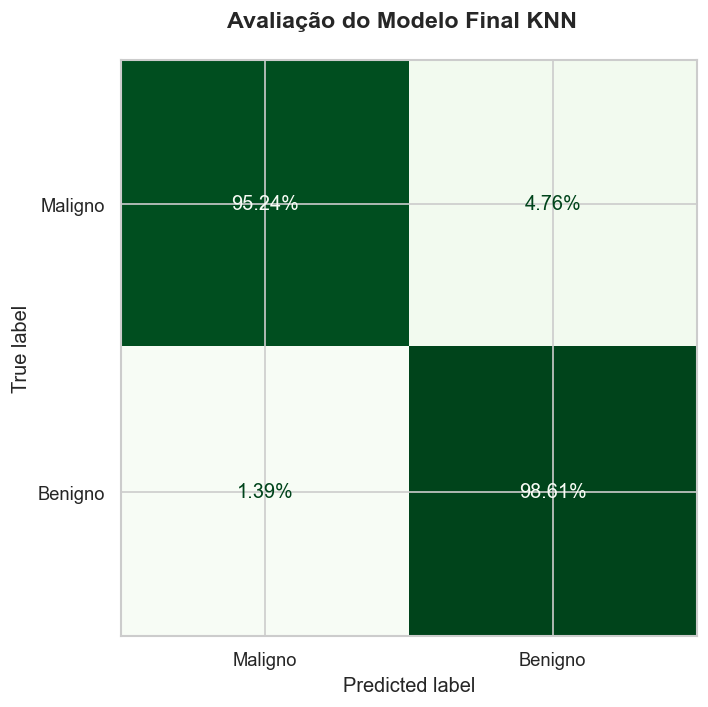


Resumo da Matriz de Confusão:
   Verdadeiros Positivos (VP Benigno correto) : 71
   Verdadeiros Negativos (VN Maligno correto) : 40
   Falsos Positivos (FP Maligno → Benigno)    : 2
   Falsos Negativos (FN Benigno → Maligno)    : 1

 Falsos Negativos são críticos no contexto médico:
 Diagnosticar um tumor Maligno como Benigno pode atrasar o tratamento.


In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

cm      = confusion_matrix(y_test, y_pred)
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')


disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm,
                                display_labels=['Maligno', 'Benigno'])
disp.plot( ax = ax, colorbar=False, cmap='Greens',
           values_format='.2%')

plt.suptitle('Avaliação do Modelo Final KNN', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('matriz.png', bbox_inches='tight', dpi=150)
plt.show()

vn, fp, fn, vp = cm.ravel()
print(f"\nResumo da Matriz de Confusão:")
print(f"   Verdadeiros Positivos (VP Benigno correto) : {vp}")
print(f"   Verdadeiros Negativos (VN Maligno correto) : {vn}")
print(f"   Falsos Positivos (FP Maligno → Benigno)    : {fp}")
print(f"   Falsos Negativos (FN Benigno → Maligno)    : {fn}")
print(f"\n Falsos Negativos são críticos no contexto médico:")
print(f" Diagnosticar um tumor Maligno como Benigno pode atrasar o tratamento.")


---
## 8. Conclusão

| Etapa | Resultado Final |
|-------|---------|
| **Dataset** | Breast Cancer Wisconsin 569 amostras, 30 features |
| **Classes** | Maligno (212) e Benigno (357) |
| **Pré-processamento** | StandardScaler é essencial para KNN por distância |
| **Melhor K** | Selecionado via CV |
| **Métricas** | Acurácia, Precisão, Recall e F1-Score |

**KNN** é um algoritmo simples, interpretável e eficaz para datasets médicos tabulares com bom desempenho após escalonamento. Em aplicações reais de diagnóstico, o **recall da classe maligna** é a métrica mais crítica — um falso negativo (tumor maligno classificado como benigno) tem consequências graves ao paciente.
